# Project Phase II: Applied Data Engineering and Machine Learning

## Original LCS System on raw Dataset

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the original dataset
df = pd.read_csv(
    "../data/student-course-completion-prediction-dataset-original.csv"
)

# Select a reproducible 5,000-row stratified sample.
# This keeps the Completed / Not Completed proportions similar
# while reducing the computational cost of eLCS.
df_copy, _ = train_test_split(
    df,
    train_size=5000,
    random_state=42,
    stratify=df["Completed"]
)

# Reset the row index after sampling
df_copy = df_copy.reset_index(drop=True)

print(f"Total selected: {len(df_copy)}")
print(df_copy["Completed"].value_counts())

Total selected: 5000
Completed
Not Completed    2549
Completed        2451
Name: count, dtype: int64


In [3]:
for col in df_copy.columns:
    print(f"{col}: {df_copy[col].dtype}, unique: {df_copy[col].nunique(dropna=True)}")

Student_ID: str, unique: 5000
Name: str, unique: 300
Gender: str, unique: 3
Age: int64, unique: 29
Education_Level: str, unique: 5
Employment_Status: str, unique: 4
City: str, unique: 15
Device_Type: str, unique: 3
Internet_Connection_Quality: str, unique: 3
Course_ID: str, unique: 8
Course_Name: str, unique: 8
Category: str, unique: 5
Course_Level: str, unique: 3
Course_Duration_Days: int64, unique: 8
Instructor_Rating: float64, unique: 7
Login_Frequency: int64, unique: 15
Average_Session_Duration_Min: int64, unique: 67
Video_Completion_Rate: float64, unique: 829
Discussion_Participation: int64, unique: 11
Time_Spent_Hours: float64, unique: 174
Days_Since_Last_Login: int64, unique: 50
Notifications_Checked: int64, unique: 17
Peer_Interaction_Score: float64, unique: 98
Assignments_Submitted: int64, unique: 11
Assignments_Missed: int64, unique: 11
Quiz_Attempts: int64, unique: 14
Quiz_Score_Avg: float64, unique: 582
Project_Grade: float64, unique: 692
Progress_Percentage: float64, uniqu

In [4]:
# Start from the raw working dataset
baseline_df = df_copy.copy()

# Remove columns that should not be predictors
baseline_df = baseline_df.drop(
    columns=[
        "Student_ID",  # identifier only
        "Name",  # free-text identifier
    ],
    errors="ignore",
)

# Convert Enrollment_Date only because eLCS needs numeric input
if "Enrollment_Date" in baseline_df.columns:
    baseline_df["Enrollment_Date"] = pd.to_datetime(
        baseline_df["Enrollment_Date"], dayfirst=True
    )

    baseline_df["Enrollment_Year"] = baseline_df["Enrollment_Date"].dt.year
    baseline_df["Enrollment_Month"] = baseline_df["Enrollment_Date"].dt.month
    baseline_df["Enrollment_Day"] = baseline_df["Enrollment_Date"].dt.day

    baseline_df = baseline_df.drop(columns=["Enrollment_Date"])

# Separate target from predictors
y_baseline = baseline_df["Completed"].copy()
X_baseline = baseline_df.drop(columns=["Completed"]).copy()

# Convert categorical predictors to numeric codes
categorical_cols = X_baseline.select_dtypes(
    include=["object", "string", "category"]
).columns

for col in categorical_cols:
    X_baseline[col] = X_baseline[col].astype("category").cat.codes

# Convert target to binary numeric values
y_baseline = y_baseline.map({"Completed": 1, "Not Completed": 0})

# Verify that the minimally processed baseline is ready
print("Baseline feature shape:", X_baseline.shape)
print("Baseline target shape:", y_baseline.shape)

print("\nNon-numeric predictor columns:")
print(X_baseline.select_dtypes(exclude="number").columns.tolist())

print("\nMissing target values:")
print(y_baseline.isna().sum())

print("\nTarget classes:")
print(set(y_baseline))

Baseline feature shape: (5000, 39)
Baseline target shape: (5000,)

Non-numeric predictor columns:
[]

Missing target values:
0

Target classes:
{0, 1}


In [5]:
from sklearn.model_selection import train_test_split

# Split the minimally processed baseline data
X_train, X_test, y_train, y_test = train_test_split(
    X_baseline, y_baseline, test_size=0.20, random_state=42, stratify=y_baseline
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training features: (4000, 39)
Testing features: (1000, 39)
Training target: (4000,)
Testing target: (1000,)

Training class distribution:
Completed
0    2039
1    1961
Name: count, dtype: int64

Testing class distribution:
Completed
0    510
1    490
Name: count, dtype: int64


In [6]:
from skeLCS import eLCS

print("eLCS import successful")

# Create the original eLCS baseline model
baseline_elcs_model = eLCS(learning_iterations=5000, track_accuracy_while_fit=False)

print("Baseline eLCS model created.")

eLCS import successful
Baseline eLCS model created.


In [7]:
# Train the original eLCS model
baseline_elcs_model = baseline_elcs_model.fit(X_train.values, y_train.values)

print("eLCS training complete")

eLCS training complete


Original eLCS Baseline Performance
----------------------------------
Accuracy:          0.4820
Precision:         0.4825
Recall:            0.7898
F1 Score:          0.5991
Balanced Accuracy: 0.4880
Mean Cost: 4.2530
ROC AUC: 0.5061
PRC AUC: 0.5669

Confusion Matrix:
[[ 95 415]
 [103 387]]


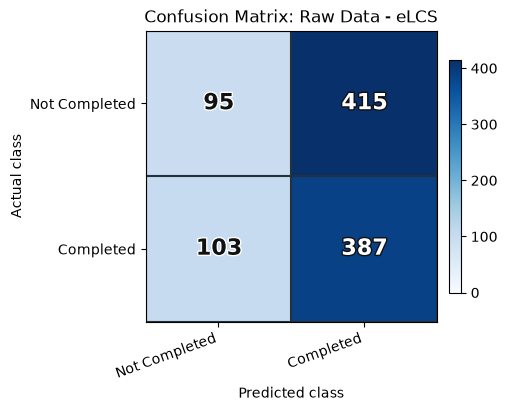

Roc/PRC curves


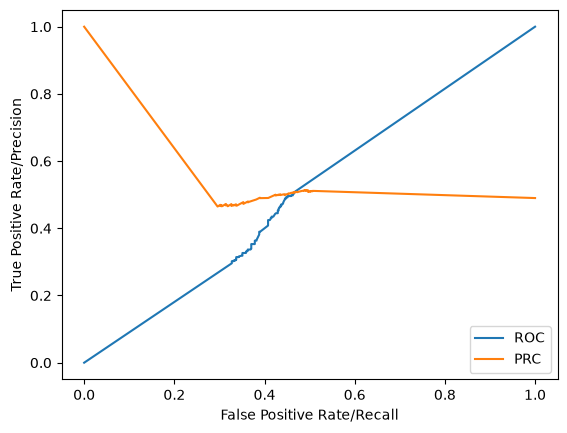

Final Training Accuracy: 0.5971159283317482
Final Instance Coverage: 0.744
Final Attribute Specificity List: [476, 462, 479, 451, 479, 501, 453, 438, 441, 460, 462, 475, 514, 439, 463, 467, 479, 490, 466, 438, 464, 455, 476, 500, 469, 510, 487, 468, 447, 515, 496, 487, 469, 471, 470, 499, 468, 469, 477]
Final Attribute Accuracy List: [468.2352548036759, 460.35, 471.68333333333334, 447.3130325814537, 476.80555555555554, 483.534857978279, 447.6805555555555, 434.71230158730157, 434.80555555555554, 452.47969924812037, 457.6444444444444, 466.75, 509.95, 434.2916666666667, 453.71666666666664, 464.08803258145366, 465.7368421052632, 470.83186375028475, 457.4688311688311, 435.28968253968253, 461.5972222222222, 445.6096415280626, 471.1722222222222, 483.0130325814537, 451.97749867091966, 489.9675153793575, 477.9570802005013, 464.76190476190476, 444.275, 494.3594250778461, 478.73232323232327, 478.18589466089463, 465.7, 460.390593909015, 459.65073099415207, 481.4720057720058, 462.66184210526313, 45

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
)

# Make predictions on the test dataset
y_pred_baseline = baseline_elcs_model.predict(X_test.values)
probabilities = baseline_elcs_model.predict_proba(X_test.values)

# Calculate baseline performance metrics
accuracy = accuracy_score(y_test, y_pred_baseline)
precision = precision_score(y_test, y_pred_baseline)
recall = recall_score(y_test, y_pred_baseline)
f1 = f1_score(y_test, y_pred_baseline)
balanced_acc = balanced_accuracy_score(y_test, y_pred_baseline)
false_negative_cost = 10.0
false_positive_cost = 1.0
false_negatives = ((y_test == 0) & (y_pred_baseline == 1)).sum()
false_positives = ((y_test == 1) & (y_pred_baseline == 0)).sum()
mean_cost = (
    false_negative_cost * false_negatives
    + false_positive_cost * false_positives
) / len(y_test)

# Receiver Operating Characteristic curve
fpr, tpr, thresholds_roc = roc_curve(y_test, probabilities[:, 1])
# Precision-Recall curve
precision_curve, recall_curve, thresholds_prc = precision_recall_curve(
    y_test, probabilities[:, 1]
)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_baseline)

print("Original eLCS Baseline Performance")
print("----------------------------------")
print(f"Accuracy:          {accuracy:.4f}")
print(f"Precision:         {precision:.4f}")
print(f"Recall:            {recall:.4f}")
print(f"F1 Score:          {f1:.4f}")
print(f"Balanced Accuracy: {balanced_acc:.4f}")
print(f"Mean Cost: {mean_cost:.4f}")
print(f"ROC AUC: {auc(fpr, tpr):.4f}")
print(f"PRC AUC: {auc(recall_curve, precision_curve):.4f}")

print("\nConfusion Matrix:")
print(cm)

# Plot confusion matrix using the same style as the improved notebook.
class_labels = ["Not Completed", "Completed"]
fig, axis = plt.subplots(figsize=(5, 4), constrained_layout=True)
image = axis.imshow(cm, cmap="Blues", vmin=0, vmax=max(cm.max(), 1))
axis.set_title("Confusion Matrix: Raw Data - eLCS")
axis.set_xlabel("Predicted class")
axis.set_ylabel("Actual class")
axis.set_xticks(range(len(class_labels)), labels=class_labels, rotation=20, ha="right")
axis.set_yticks(range(len(class_labels)), labels=class_labels)
axis.set_xticks([index - 0.5 for index in range(cm.shape[1] + 1)], minor=True)
axis.set_yticks([index - 0.5 for index in range(cm.shape[0] + 1)], minor=True)
axis.grid(which="minor", color="#24313D", linestyle="-", linewidth=1.5)
axis.tick_params(which="minor", bottom=False, left=False)

threshold = cm.max() / 2
for row_index in range(cm.shape[0]):
    for column_index in range(cm.shape[1]):
        value = cm[row_index, column_index]
        text_color = "white" if value > threshold else "#111111"
        outline_color = "#111111" if text_color == "white" else "white"
        axis.text(
            column_index,
            row_index,
            str(value),
            ha="center",
            va="center",
            fontsize=16,
            fontweight="bold",
            color=text_color,
            path_effects=[
                path_effects.withStroke(linewidth=2, foreground=outline_color)
            ],
        )

fig.colorbar(image, ax=axis, shrink=0.8, pad=0.04)
plt.show()

print("Roc/PRC curves")
plt.plot(fpr, tpr, label="ROC")
plt.plot(recall_curve, precision_curve, label="PRC")
plt.xlabel("False Positive Rate/Recall")
plt.ylabel("True Positive Rate/Precision")
plt.legend()
plt.show()

print("Final Training Accuracy: " + str(baseline_elcs_model.get_final_accuracy()))
print(
    "Final Instance Coverage: " + str(baseline_elcs_model.get_final_instance_coverage())
)
print(
    "Final Attribute Specificity List: "
    + str(baseline_elcs_model.get_final_attribute_specificity_list())
)
print(
    "Final Attribute Accuracy List: "
    + str(baseline_elcs_model.get_final_attribute_accuracy_list())
)

In [9]:
export_dir = "../data/export/"
baseline_iteration_tracking_file = (
    f"{export_dir}/baseline_elcs_model_iteration_data.csv"
)

baseline_elcs_model.export_iteration_tracking_data(baseline_iteration_tracking_file)
baseline_elcs_model_iteration_data = pd.read_csv(baseline_iteration_tracking_file)

display(baseline_elcs_model_iteration_data)

,Iteration,Accuracy (approx),Average Population Generality,Macropopulation Size,Micropopulation Size,Match Set Size,Correct Set Size,Average Iteration Age of Correct Set Classifiers,# Classifiers Subsumed in Iteration,# Crossover Operations Performed in Iteration,# Mutation Operations Performed in Iteration,# Covering Operations Performed in Iteration,# Deletion Operations Performed in Iteration,Total Global Time,Total Matching Time,Total Deletion Time,Total Subsumption Time,Total Selection Time,Total Evaluation Time
0,0,0,0.000000,1,1,1,1,0.00,0,0,0,1,0,0.528428,0.000006,0.000003,0.000000,0.000000,0.000000
1,1,0,0.000000,2,2,1,1,1.00,0,0,0,1,0,0.528482,0.000011,0.000003,0.000000,0.000000,0.000011
2,2,0,0.000000,3,3,1,1,2.00,0,0,0,1,0,0.528510,0.000014,0.000004,0.000000,0.000000,0.000015
3,3,0,0.000000,4,4,1,1,3.00,0,0,0,1,0,0.528544,0.000017,0.000005,0.000000,0.000000,0.000016
4,4,0,0.000000,5,5,1,1,4.00,0,0,0,1,0,0.528578,0.000020,0.000005,0.000000,0.000000,0.000017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4995,0,0.518000,986,1000,1,1,4995.00,0,0,0,1,1,9.169791,4.807041,3.014431,0.460388,0.011320,0.025712
4996,4996,0,0.518000,986,1000,1,1,4996.00,0,0,0,1,1,9.173653,4.809619,3.015602,0.460388,0.011320,0.025723
4997,4997,0,0.518000,986,1000,2,2,4983.00,0,0,0,0,0,9.175531,4.811442,3.015604,0.460388,0.011320,0.025736
4998,4998,0,0.518000,986,1000,2,1,4998.00,0,0,0,1,1,9.178496,4.813283,3.016632,0.460388,0.011320,0.025744


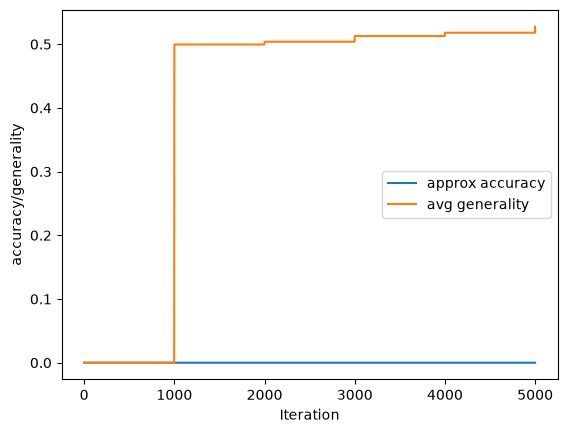

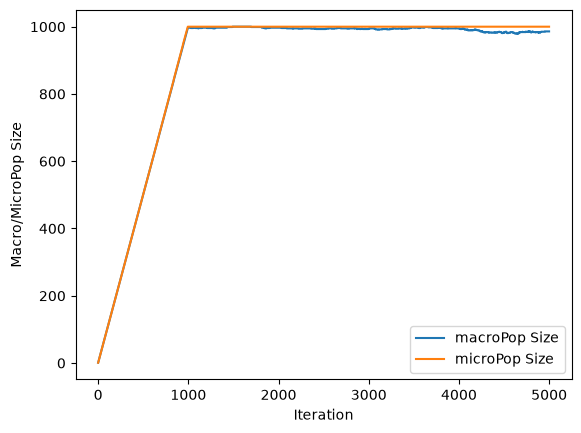

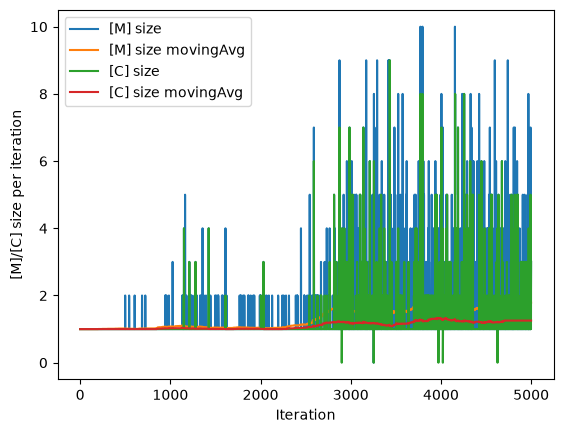

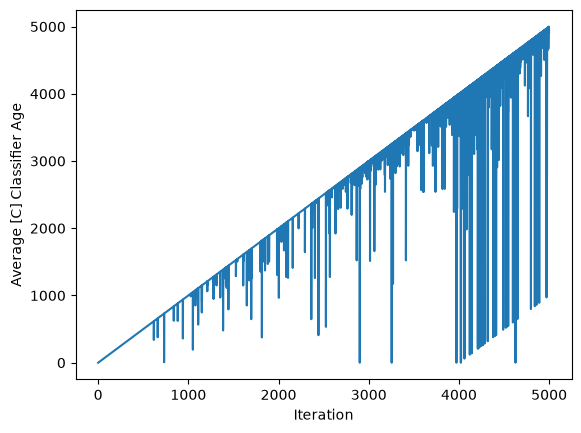

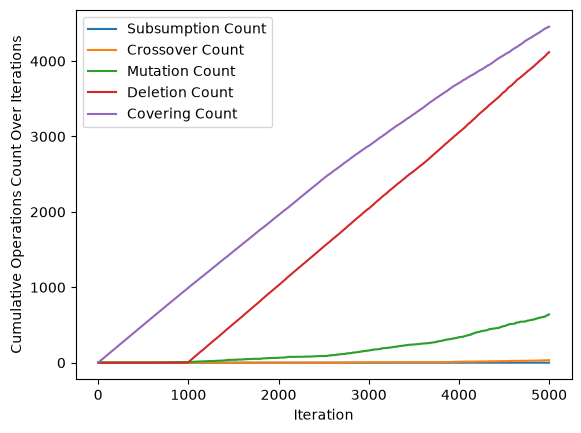

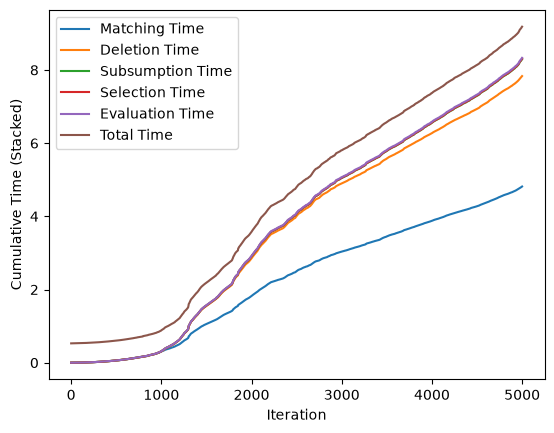

In [10]:
# Display the iteration tracking data for the baseline eLCS model
import numpy as np


def cumulativeFreq(freq):
    a = []
    c = []
    for i in freq:
        a.append(i + sum(c))
        c.append(i)
    return np.array(a)


def movingAvg(a, threshold=300):
    weights = np.repeat(1.0, threshold) / threshold
    conv = np.convolve(a, weights, "valid")
    return np.append(
        conv,
        np.full(threshold - 1, conv[conv.size - 1]),
    )


iterations = baseline_elcs_model_iteration_data["Iteration"].values
accuracy = baseline_elcs_model_iteration_data["Accuracy (approx)"].values
generality = baseline_elcs_model_iteration_data["Average Population Generality"].values
macroPop = baseline_elcs_model_iteration_data["Macropopulation Size"].values
microPop = baseline_elcs_model_iteration_data["Micropopulation Size"].values
mSize = baseline_elcs_model_iteration_data["Match Set Size"].values
cSize = baseline_elcs_model_iteration_data["Correct Set Size"].values
experience = baseline_elcs_model_iteration_data[
    "Average Iteration Age of Correct Set Classifiers"
].values
subsumption = baseline_elcs_model_iteration_data[
    "# Classifiers Subsumed in Iteration"
].values
crossover = baseline_elcs_model_iteration_data[
    "# Crossover Operations Performed in Iteration"
].values
mutation = baseline_elcs_model_iteration_data[
    "# Mutation Operations Performed in Iteration"
].values
covering = baseline_elcs_model_iteration_data[
    "# Covering Operations Performed in Iteration"
].values
deletion = baseline_elcs_model_iteration_data[
    "# Deletion Operations Performed in Iteration"
].values

gTime = baseline_elcs_model_iteration_data["Total Global Time"].values
mTime = baseline_elcs_model_iteration_data["Total Matching Time"].values
delTime = baseline_elcs_model_iteration_data["Total Deletion Time"].values
subTime = baseline_elcs_model_iteration_data["Total Subsumption Time"].values
selTime = baseline_elcs_model_iteration_data["Total Selection Time"].values
evalTime = baseline_elcs_model_iteration_data["Total Evaluation Time"].values

plt.plot(iterations, accuracy, label="approx accuracy")
plt.plot(iterations, generality, label="avg generality")
plt.xlabel("Iteration")
plt.ylabel("accuracy/generality")
plt.legend()
plt.show()

plt.plot(iterations, macroPop, label="macroPop Size")
plt.plot(iterations, microPop, label="microPop Size")
plt.xlabel("Iteration")
plt.ylabel("Macro/MicroPop Size")
plt.legend()
plt.show()

plt.plot(iterations, mSize, label="[M] size")
plt.plot(iterations, movingAvg(mSize), label="[M] size movingAvg")
plt.plot(iterations, cSize, label="[C] size")
plt.plot(iterations, movingAvg(cSize), label="[C] size movingAvg")
plt.xlabel("Iteration")
plt.ylabel("[M]/[C] size per iteration")
plt.legend()
plt.show()

plt.plot(iterations, experience)
plt.ylabel("Average [C] Classifier Age")
plt.xlabel("Iteration")
plt.show()

plt.plot(iterations, cumulativeFreq(subsumption), label="Subsumption Count")
plt.plot(iterations, cumulativeFreq(crossover), label="Crossover Count")
plt.plot(iterations, cumulativeFreq(mutation), label="Mutation Count")
plt.plot(iterations, cumulativeFreq(deletion), label="Deletion Count")
plt.plot(iterations, cumulativeFreq(covering), label="Covering Count")
plt.xlabel("Iteration")
plt.ylabel("Cumulative Operations Count Over Iterations")
plt.legend()
plt.show()

plt.plot(iterations, mTime, label="Matching Time")
plt.plot(iterations, delTime + mTime, label="Deletion Time")
plt.plot(iterations, subTime + delTime + mTime, label="Subsumption Time")
plt.plot(iterations, selTime + subTime + delTime + mTime, label="Selection Time")
plt.plot(
    iterations, evalTime + selTime + subTime + delTime + mTime, label="Evaluation Time"
)
plt.plot(iterations, gTime, label="Total Time")
plt.xlabel("Iteration")
plt.ylabel("Cumulative Time (Stacked)")
plt.legend()
plt.show()

In [11]:
# Export the final rule population to a CSV file

baseline_elcs_model_final_rule_population_file = (
    f"{export_dir}/baseline_elcs_model_final_rule_population.csv"
)

baseline_elcs_model.export_final_rule_population(
    X_baseline.columns.to_numpy(),
    "Completed",
    filename=baseline_elcs_model_final_rule_population_file,
    DCAL=False,
)

baseline_elcs_model_final_rule_populationData = pd.read_csv(
    baseline_elcs_model_final_rule_population_file
)
display(baseline_elcs_model_final_rule_populationData)

,Gender,Age,Education_Level,Employment_Status,City,Device_Type,Internet_Connection_Quality,Course_ID,Course_Name,Category,...,Fitness,Accuracy,Numerosity,Avg Match Set Size,TimeStamp GA,Iteration Initialized,Specificity,Deletion Probability,Correct Count,Match Count
0,1.0,"33.36,42.64",#,#,#,1.0,0.0,6.0,#,#,...,1.0,1.0,1,2.00,4023,23,0.384615,0.001243,2,2
1,#,#,4.0,0.0,#,#,#,#,0.0,4.0,...,1.0,1.0,1,2.00,4061,61,0.487179,0.001243,2,2
2,#,#,0.0,#,#,#,0.0,#,5.0,4.0,...,1.0,1.0,1,1.50,4084,84,0.435897,0.000932,2,2
3,#,"16.88,35.120000000000005",#,#,"7.45,16.55",#,0.0,3.0,#,#,...,1.0,1.0,1,2.50,4093,93,0.538462,0.001553,2,2
4,1.0,#,0.0,#,"5.59,14.41",0.0,2.0,#,5.0,4.0,...,1.0,1.0,1,1.00,4138,138,0.538462,0.000621,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
981,#,"17.2,26.8",0.0,0.0,#,#,#,5.0,4.0,4.0,...,1.0,1.0,1,1.00,4995,4995,0.589744,0.000621,1,1
982,#,"20.560000000000002,39.44",0.0,#,#,#,2.0,3.0,#,2.0,...,1.0,1.0,1,1.00,4996,4996,0.564103,0.000621,1,1
983,0.0,#,#,2.0,#,#,0.0,0.0,#,4.0,...,1.0,1.0,1,2.00,4998,4998,0.641026,0.001243,1,1
984,#,#,#,#,#,#,#,#,#,#,...,0.1,1.0,1,2.25,4999,4999,0.153846,0.001398,0,0


Minimal processing: 
-Student_ID removed because it is only an identifier and not a meaningful predictor.
-Name removed because it is free-text/identifier information.
-Completed_Status removed because it was derived from the target and would cause target leakage.
-Enrollment_Date converted into numeric year/month/day values because eLCS requires numeric inputs.
-Categorical predictors such as Gender, City, Course_Level, etc. converted into numeric category codes so eLCS could process them.
-Completed converted from Completed / Not Completed into 1 / 0 because the model needs numeric class labels.
-No feature engineering, scaling, tuning, balancing, or optimisation was applied at this stage, so this remains the raw/minimally processed baseline.